In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# auxiliary function for creating a csv and ploting the binary classes
def csvBinaryClass(X1,Y1,X2,Y2,name):
    
    dataC1 = np.vstack((X1,Y1,np.zeros(Y1.shape))).T
    dataC2 = np.vstack((X2,Y2,np.ones (Y2.shape))).T    
    data = np.concatenate((dataC1,dataC2))
    
    df = pd.DataFrame(data,columns=['f1','f2','Class'])    
    df.to_csv('datasets/'+name+ '.csv',index=False)    
    return df

def pngBinaryClass(X1,Y1,X2,Y2,name,n):
    
    plt.scatter(X1, Y1, label= 'Class1', s=100, marker='+', facecolors='b',  edgecolors='b')
    plt.scatter(X2, Y2, label= 'Class2', s=100, marker='o', facecolors='none',  edgecolors='r')#, fillstyle ='none')    
    w = plt.xlabel('x', fontsize=16, x=0.9, y=0.9)
    h = plt.ylabel('y', fontsize=16, x=0.9, y=0.9)
    h.set_rotation(0)
    
    plt.legend()#loc='lower left')
    plt.xlim([0, n+1])
    plt.ylim([0, n+1])
    plt.xticks(np.arange(n,step=int(n/3)))
    plt.yticks(np.arange(n,step=int(n/3)))
    plt.savefig('figures/'+name+ '.png', bbox_inches='tight')

def csvPngBClass(X1,Y1,X2,Y2,name):
    pngBinaryClass(X1,Y1,X2,Y2,name)
    csvBinaryClass(X1,Y1,X2,Y2,name)
    
def setFig():
    fig = plt.figure()
    # set up the figure box to a traditional two axeses    
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['left'].set_position(('data',0))
    ax.spines['bottom'].set_position(('data',0))
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    return ax
    


In [4]:
import math
def log2(x):
    if x==0: return 0 # a bit of abuse of the concept log to avoid infinity, this is because when we the pr=0 the pr*log(pr)=0 by defenition
    return math.log2(x)

def ent(s): # entropy
    sm = s[0] + s[1]
    return -(s[0]/sm)*log2(s[0]/sm)-(s[1]/sm)*log2(s[1]/sm)

def gini(s):
    sm = s[0] + s[1]
    return (s[0]/sm)*(1-s[0]/sm) + (s[1]/sm)*(1-s[1]/sm)


20 20 Balanced


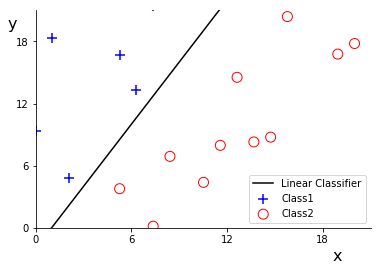

In [3]:
name = 'DiagonalDBoundaryC1C2'
n = 20
x = np.linspace(0, n, num = n) # this sampling unifromally from the x axis

# boundaries
y = 2*x - 2 # boundary

# generate data that satisfies the conditions
Y1 =  np.random.random(n)*(n) + (y+2)
Y2 = -np.random.random(n)*(n) + (y-2)

# plot classes and boundaries and save data
ax = setFig()

plt.plot(x, y, 'k', label='Linear Classifier')
#plt.title('Linear Model with Linearly Separable Classes')


pngBinaryClass(x,Y1,x,Y2,name,n)
csvBinaryClass(x,Y1,x,Y2,name)

print(len(Y1),len(Y2),'Balanced')

In [5]:
def gain_index(s1,s2, fun = ent):
    sm1 = s1[0] + s1[1]
    sm2 = s2[0] + s2[1]
    sm  = sm1 + sm2 
    return (sm1/sm)*fun(s1) + (sm2/sm)*fun(s2)


In [6]:
def info_gain(s1,s2, fun = ent):
    s = [s1[0]+s2[0], s1[1]+s2[1]]
    return ent(s) - gain_index(s1,s2,fun)
    

In [7]:
s  = [7, 9] # original set #C1 =7, C2=9
s1 = [6, 2] # subset 1     #C1 =6, C2=2
s2 = [1, 7] # subset 2     #C1 =1, C2=7

ents  = -(7/16)*log2(7/16)-(9/16)*log2(9/16)
ents1 = -(6/8)*log2(6/8)-(2/8)*log2(2/8)
ents2 = -(1/8)*log2(1/8)-(7/8)*log2(7/8)
infoG = ents - (8/16)*ents1 - (8/16)*ents2
print(ents)
print(ents1)
print(ents2)

print(infoG)
print(info_gain(s1,s2))

0.9886994082884974
0.8112781244591328
0.5435644431995964
0.3112781244591328
0.31127812445913283


In [8]:
s  = [7, 9] # original set #C1 =7, C2=9
s1 = [7, 4] # subset 1     #C1 =6, C2=2
s2 = [0, 5] # subset 2     #C1 =1, C2=7

ents  = -(7/16)*log2(7/16) - (9/16)*log2(9/16)

ents1 = -(7/11)*log2(7/11) - (4/11)*log2(4/11)
ents2 = -( 0/5)*log2( 0/5) - (5/5 )*log2(5/5)
infoG = ents - (11/16)*ents1 - (5/16)*ents2

print(ents)
print(ents1)
print(ents2)

print(infoG)
print(info_gain(s1,s2))

0.9886994082884974
0.9456603046006402
-0.0
0.33855794887555735
0.33855794887555735
